In [2]:
##tools
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [4]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv, verbose=True,description="Query Arxiv papers")
print(arxiv.description)

Query Arxiv papers


In [6]:
arxiv.invoke("What is the latest ai tool?")

Published: 2025-04-02
Title: What is AI, what is it not, how we use it in physics and how it impacts... you
Authors: Claire David
Summary: Artificial Intelligence (AI) and Machine Learning (ML) have been prevalent in
particle physics for over three decades, shaping many aspects of High Energy
Physics (HEP) analyses. As AI's influence grows, it is essential for physicists
$\unicode{x2013}$ as both researchers and informed citizens $\unicode{x2013}$
to critically examine its foundations, misconcep

"Published: 2025-04-02\nTitle: What is AI, what is it not, how we use it in physics and how it impacts... you\nAuthors: Claire David\nSummary: Artificial Intelligence (AI) and Machine Learning (ML) have been prevalent in\nparticle physics for over three decades, shaping many aspects of High Energy\nPhysics (HEP) analyses. As AI's influence grows, it is essential for physicists\n$\\unicode{x2013}$ as both researchers and informed citizens $\\unicode{x2013}$\nto critically examine its foundations, misconcep"

In [7]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki, verbose=True,description="Query Wikipedia")
print(wiki.description)

Query Wikipedia


In [9]:
wiki.invoke("Which is the latest ai model in openai tool?")

Page: OpenAI o1
Summary: OpenAI o1 is a reflective generative pre-trained transformer (GPT). A preview of o1 was released by OpenAI on September 12, 2024. o1 spends time "thinking" before it answers, making it better at complex reasoning tasks, science and programming than GPT-4o. The full version was released to ChatGPT users on December 5, 2024.

'Page: OpenAI o1\nSummary: OpenAI o1 is a reflective generative pre-trained transformer (GPT). A preview of o1 was released by OpenAI on September 12, 2024. o1 spends time "thinking" before it answers, making it better at complex reasoning tasks, science and programming than GPT-4o. The full version was released to ChatGPT users on December 5, 2024.'

In [10]:
wiki.invoke("Who is the father of nation india ?")

Page: Father of the Nation
Summary: The Father of the Nation is an honorific title given to a person considered the driving force behind the establishment of a country, state, or nation. Pater Patriae was a Roman honorific meaning the "Father of the Fatherland", bestowed by the Senate on heroes, and later on emperors. In monarchies, the monarch is often considered the "father/mother of the nation" or as a patriarch to guide his family. This concept is expressed in the divine right of kings espou

'Page: Father of the Nation\nSummary: The Father of the Nation is an honorific title given to a person considered the driving force behind the establishment of a country, state, or nation. Pater Patriae was a Roman honorific meaning the "Father of the Fatherland", bestowed by the Senate on heroes, and later on emperors. In monarchies, the monarch is often considered the "father/mother of the nation" or as a patriarch to guide his family. This concept is expressed in the divine right of kings espou'

In [11]:
from dotenv import load_dotenv
import os
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [12]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults(api_key=os.getenv("TAVILY_API_KEY"), top_k_results=2, doc_content_chars_max=500)

In [13]:
tavily.invoke("What is the latest ai tool?")

[{'title': '10+ AI Tools You Can Start Using For Free | Google Cloud',
  'url': 'https://cloud.google.com/use-cases/free-ai-tools',
  'content': 'Try Gemini 2.0 Flash, our newest model with low latency and enhanced performance in Google AI Studio\n\nFree AI tools from Google Cloud\n\nWork with the latest AI models and turn your ideas into apps with free AI tools\n\nGoogle AI Studio is the fast path for developers, students, and researchers who want to try Gemini models and start building with the Gemini Developer API. We also offer free tools for common AI use cases, including translation, image and video analysis, speech-to-text, and more.',
  'score': 0.5914643},
 {'title': '7 Best AI Tools You NEED to Try in 2025 (Free & Powerful!) - YouTube',
  'url': 'https://www.youtube.com/watch?v=TZe5UqlUg0c',
  'content': '🛠️ Featured AI Tools:\n1️⃣ Zapier – Automate repetitive tasks and connect thousands of apps. Tutorial that walks through how to get started: https://youtu.be/JtdUgJGI_Oo\n2️

In [14]:
tools = [arxiv, wiki, tavily]

In [21]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen-qwq-32b")

In [23]:
answer = llm.invoke("What is AI?")

In [24]:
answer = str(answer)

In [26]:
answer.replace("\n","")

'content=\'\\n<think>\\nOkay, so I need to explain what AI is. Let\\\'s start with the basics. AI stands for Artificial Intelligence. But what does that really mean? I think it\\\'s when machines can perform tasks that typically require human intelligence. Hmm, right. But how do I break that down further?\\n\\nMaybe I should mention different types of AI. I remember hearing terms like narrow AI and general AI. Narrow AI is like the stuff we see now, like voice assistants. They can do specific tasks but aren\\\'t sentient. General AI, or AGI, would be human-like intelligence that can handle any task, but that\\\'s still theoretical, right?\\n\\nWait, the user might also want to know about techniques. Machine learning comes to mind. That\\\'s where AI learns from data instead of being programmed explicitly. Deep learning is a subset of that, using neural networks. Maybe I should explain those briefly.\\n\\nApplications are important too. Examples help people understand better. Like, imag

In [27]:
answer 

'content=\'\\n<think>\\nOkay, so I need to explain what AI is. Let\\\'s start with the basics. AI stands for Artificial Intelligence. But what does that really mean? I think it\\\'s when machines can perform tasks that typically require human intelligence. Hmm, right. But how do I break that down further?\\n\\nMaybe I should mention different types of AI. I remember hearing terms like narrow AI and general AI. Narrow AI is like the stuff we see now, like voice assistants. They can do specific tasks but aren\\\'t sentient. General AI, or AGI, would be human-like intelligence that can handle any task, but that\\\'s still theoretical, right?\\n\\nWait, the user might also want to know about techniques. Machine learning comes to mind. That\\\'s where AI learns from data instead of being programmed explicitly. Deep learning is a subset of that, using neural networks. Maybe I should explain those briefly.\\n\\nApplications are important too. Examples help people understand better. Like, imag

In [28]:
llm_with_tools = llm.bind_tools(tools=tools)


In [29]:
llm_with_tools.invoke("WHat is the latest ai news?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_eq40', 'function': {'arguments': '{"query": "latest AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 184, 'prompt_tokens': 322, 'total_tokens': 506, 'completion_time': 0.456621909, 'prompt_time': 0.024992039, 'queue_time': 0.24804022300000003, 'total_time': 0.481613948}, 'model_name': 'qwen-qwq-32b', 'system_fingerprint': 'fp_512a3da6bb', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--e3e5a9a9-b694-4fe6-bb06-30776f8325ec-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest AI news'}, 'id': 'call_eq40', 'type': 'tool_call'}], usage_metadata={'input_tokens': 322, 'output_tokens': 184, 'total_tokens': 506})

In [30]:
llm_with_tools.invoke("What is the latest research paper on AI?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_rm3t', 'function': {'arguments': '{"query": "AI"}', 'name': 'arxiv'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 384, 'prompt_tokens': 323, 'total_tokens': 707, 'completion_time': 0.933058271, 'prompt_time': 0.021869359, 'queue_time': 0.247570472, 'total_time': 0.95492763}, 'model_name': 'qwen-qwq-32b', 'system_fingerprint': 'fp_3796682456', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--23fc9251-bda7-41ba-8ce1-d98d7d8db560-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'AI'}, 'id': 'call_rm3t', 'type': 'tool_call'}], usage_metadata={'input_tokens': 323, 'output_tokens': 384, 'total_tokens': 707})

In [33]:
llm_with_tools.invoke("What is the India?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_3z1n', 'function': {'arguments': '{"query": "India"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 131, 'prompt_tokens': 319, 'total_tokens': 450, 'completion_time': 0.317771018, 'prompt_time': 0.018025527, 'queue_time': 0.251346493, 'total_time': 0.335796545}, 'model_name': 'qwen-qwq-32b', 'system_fingerprint': 'fp_512a3da6bb', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--831928c8-c26c-4c60-86ed-e2b9a7e1e53c-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'India'}, 'id': 'call_3z1n', 'type': 'tool_call'}], usage_metadata={'input_tokens': 319, 'output_tokens': 131, 'total_tokens': 450})

In [34]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

In [35]:
class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]



In [36]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [37]:
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}



In [44]:
graphbuilder = StateGraph(State)
graphbuilder.add_node("tool_calling_llm",tool_calling_llm)
graphbuilder.add_node("tools",ToolNode(tools))

In [45]:
graphbuilder.add_edge(START,"tool_calling_llm")
graphbuilder.add_conditional_edges("tool_calling_llm",tools_condition)
graphbuilder.add_edge("tools",END)

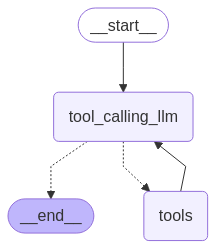

In [60]:
graphbuilder2 = StateGraph(State)
graphbuilder2.add_node("tool_calling_llm",tool_calling_llm)
graphbuilder2.add_node("tools",ToolNode(tools))

graphbuilder2.add_edge(START,"tool_calling_llm")
graphbuilder2.add_conditional_edges("tool_calling_llm",tools_condition)
graphbuilder2.add_edge("tools","tool_calling_llm")
graphbuilder2.add_edge("tool_calling_llm",END)

graph2 = graphbuilder2.compile()
display(Image(graph2.get_graph().draw_mermaid_png()))

In [63]:
from langchain_core.messages import HumanMessage

messages = graph2.invoke({"messages": "HI Good Morning?"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

HI Good Morning?
================================== Ai Message ==================================

Good morning! 😊 How can I assist you today? Let me know if you have any questions or need help with something specific!


In [47]:
graph = graphbuilder.compile()

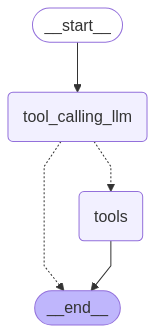

In [49]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [62]:
from langchain_core.messages import HumanMessage

messages = graph.invoke({"messages": "Hi Good Morning?"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi Good Morning?
================================== Ai Message ==================================

Good morning! 😊 How can I assist you today? If you have any questions or need help with something specific, just let me know!


In [2]:
import streamlit as st 
st.write("Agentic AI")
st.write("Ask me anything about AI")
user_input = st.text_input("Enter your question:")  
if user_input:
    messages = graph2.invoke({"messages": user_input})
    st.write("Response:")
    for m in messages['messages']:
        st.write(m.content)

2025-05-03 20:48:54.085 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 20:48:54.086 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 20:48:54.088 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 20:48:54.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 20:48:54.091 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 20:48:54.092 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 20:48:54.093 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-03 20:48:54.094 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar